### PLOTTER NOTEBOOK

In [19]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt

In [20]:
### Read the photometry file
photpath = os.path.join(
        '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/',
        'test_polar_v0_static.h5')
results = readPhotometry(photpath)

### Read codecs and spectra timeseries
runname = 'timeSeries_1200k_clouds=10_polarStatic'
dirPath = os.path.join(os.getcwd(), runname)
# Search for files matching the pattern 'i=*.h5' in the directory
spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

# Initialize the specs dictionary
specs = {}
codecs = {}

# Iterate through each file and load spectra
for index, file in enumerate(spectra_files):
    inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename
    
    specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
    codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

# Load the json config codec_config.json
configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
codec_loaded = CodecSystem()
codec_loaded.import_mapping(configPath, validate_files=False)

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeSeries_1200k_clouds=10_polarStatic/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20


{'0': 0.00314460893413552, '1': 0.057349625949485235, '2': 0.02000201025228666, '3': 0.013095357753112302, '4': 0.010467670835547003, '5': 0.008916904785836337, '6': 0.008328188044742472, '7': 0.007337420846316212, '8': 0.007509728185172954, '9': 0.12143359705928808, '10': 0.7095903393018681, '11': 0.007940496532314805, '12': 0.003489223611849001, '13': 0.0023117901296612724, '14': 0.0018092270579957784, '15': 0.000933331418807346, '16': 0.0008471777493789756, '17': 0.0005169220165702225, '18': 0.014315868070014216, '19': 0.0006605114656175064}


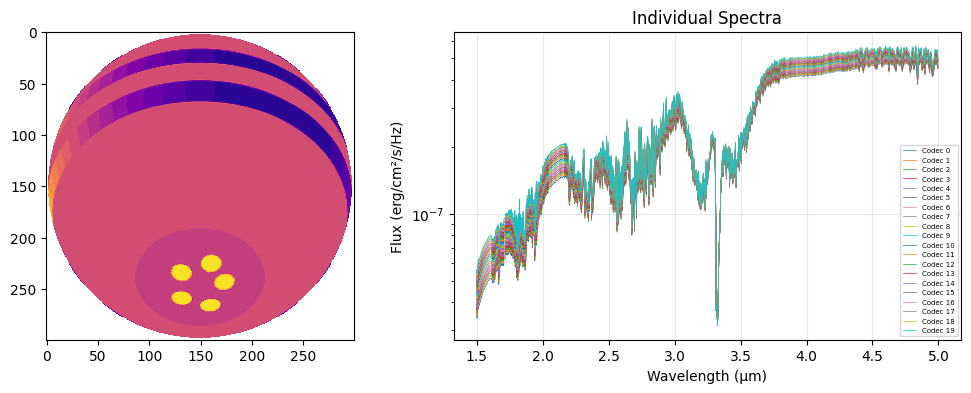

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1.5])
ax = axes[0]
frame_id = 22
ax.imshow(codecs['40'][frame_id]['composite'], cmap='plasma')
print(codecs['40'][frame_id]['fractions']['fractions'])

# ===== Plot 1: All individual spectra =====
ax = axes[1]
for codec_id in range(n):  # Plot all codec
    wave_i, flux_i = codec_loaded.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, label=f'Codec {codec_id}')
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux (erg/cm²/s/Hz)')
ax.set_title('Individual Spectra')
ax.legend(fontsize=5)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.show()
plt.close(fig)

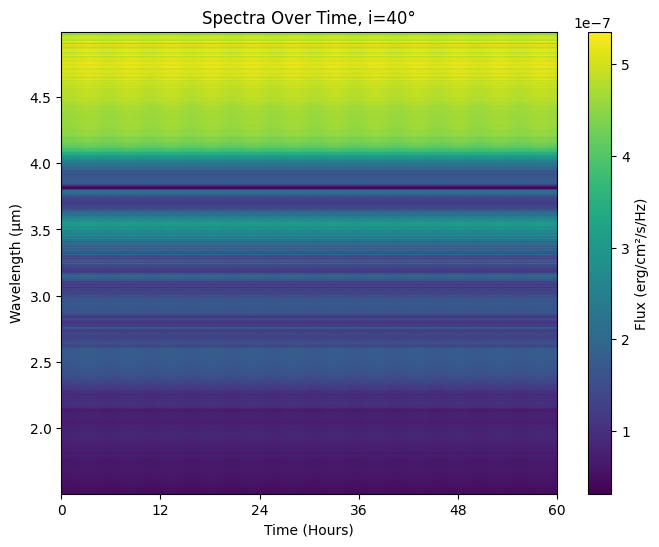

In [ ]:
# ===== Plot: 2D image of spectra over time =====
fig, ax = plt.subplots(figsize=(8, 6))

for inclin in specs.keys():
    fig, ax = plt.subplots(figsize=(10, 4))
    # Prepare data for the 2D image
    time_indices = results[inclin]['time_array']
    time_indices.sort()
    flux_matrix = []
    for keys in specs[inclin].keys():
        _, wave_i, flux_i = specs[inclin][keys].values()
        flux_matrix.append(flux_i)

    flux_matrix = np.array(flux_matrix)

    # Plot the 2D image
    im = ax.imshow(flux_matrix.T, aspect='auto', origin='lower', 
                    extent=[time_indices[0], time_indices[-1], wave_i[0], wave_i[-1]],
                    cmap='viridis')

    ax.set_xlabel('Time (Hours)')
    ax.set_xticks([])
    ax.set_xticks(np.linspace(time_indices[0], time_indices[-1], num=6, dtype=int))
    ax.set_ylabel('Wavelength (μm)')
    ax.set_title(f'Spectra Over Time, i={inclin}°')
    plt.colorbar(im, ax=ax, label='Flux (erg/cm²/s/Hz)')

    plt.show()
    plt.close()

### Necessary Metadata

In [25]:
### Somes helpful metadata
# codec length
n = len(codec_loaded.spectra_assignments.keys())
# how to load a spectrum
wave, flux = codec_loaded.load_spectrum(codec_id=0)
print(wave[::50])
print(flux[::50])
# load the time indices 
time_indices = results['0']['time_array']

[1.50052115 1.61162191 1.73094872 1.85911066 1.9967619  2.14460503
 2.30339469 2.47394136 2.65711554 2.85385222 3.06515555 3.2921041
 3.53585624 3.79765614 4.07884008 4.38084329 4.70520725]
[3.51057200e-08 5.12749234e-08 6.55794092e-08 5.82685599e-08
 1.08362015e-07 1.46963972e-07 1.29791016e-07 1.33802824e-07
 1.72058953e-07 1.30520526e-07 2.43006176e-07 1.99454720e-07
 2.23488051e-07 4.09263574e-07 4.25103414e-07 4.50129622e-07
 4.63230398e-07]


In [ ]:
time, wave, flux = composite_spectra_ts[0].values()

array([1.50052115, 1.50266629, 1.50481449, 1.50696576, 1.50912011,
       1.51127753, 1.51343805, 1.51560165, 1.51776834, 1.51993813,
       1.52211102, 1.52428702, 1.52646613, 1.52864835, 1.5308337 ,
       1.53302217, 1.53521376, 1.53740849, 1.53960636, 1.54180737,
       1.54401153, 1.54621883, 1.5484293 , 1.55064292, 1.55285971,
       1.55507967, 1.5573028 , 1.5595291 , 1.5617586 , 1.56399127,
       1.56622714, 1.56846621, 1.57070848, 1.57295395, 1.57520263,
       1.57745453, 1.57970965, 1.58196799, 1.58422956, 1.58649436,
       1.5887624 , 1.59103369, 1.59330822, 1.595586  , 1.59786704,
       1.60015134, 1.6024389 , 1.60472973, 1.60702384, 1.60932123,
       1.61162191, 1.61392587, 1.61623313, 1.61854368, 1.62085754,
       1.62317471, 1.62549518, 1.62781898, 1.6301461 , 1.63247654,
       1.63481032, 1.63714743, 1.63948789, 1.64183168, 1.64417884,
       1.64652934, 1.64888321, 1.65124044, 1.65360104, 1.65596502,
       1.65833237, 1.66070311, 1.66307724, 1.66545476, 1.66783

### 1 - Plot all cloud codec images

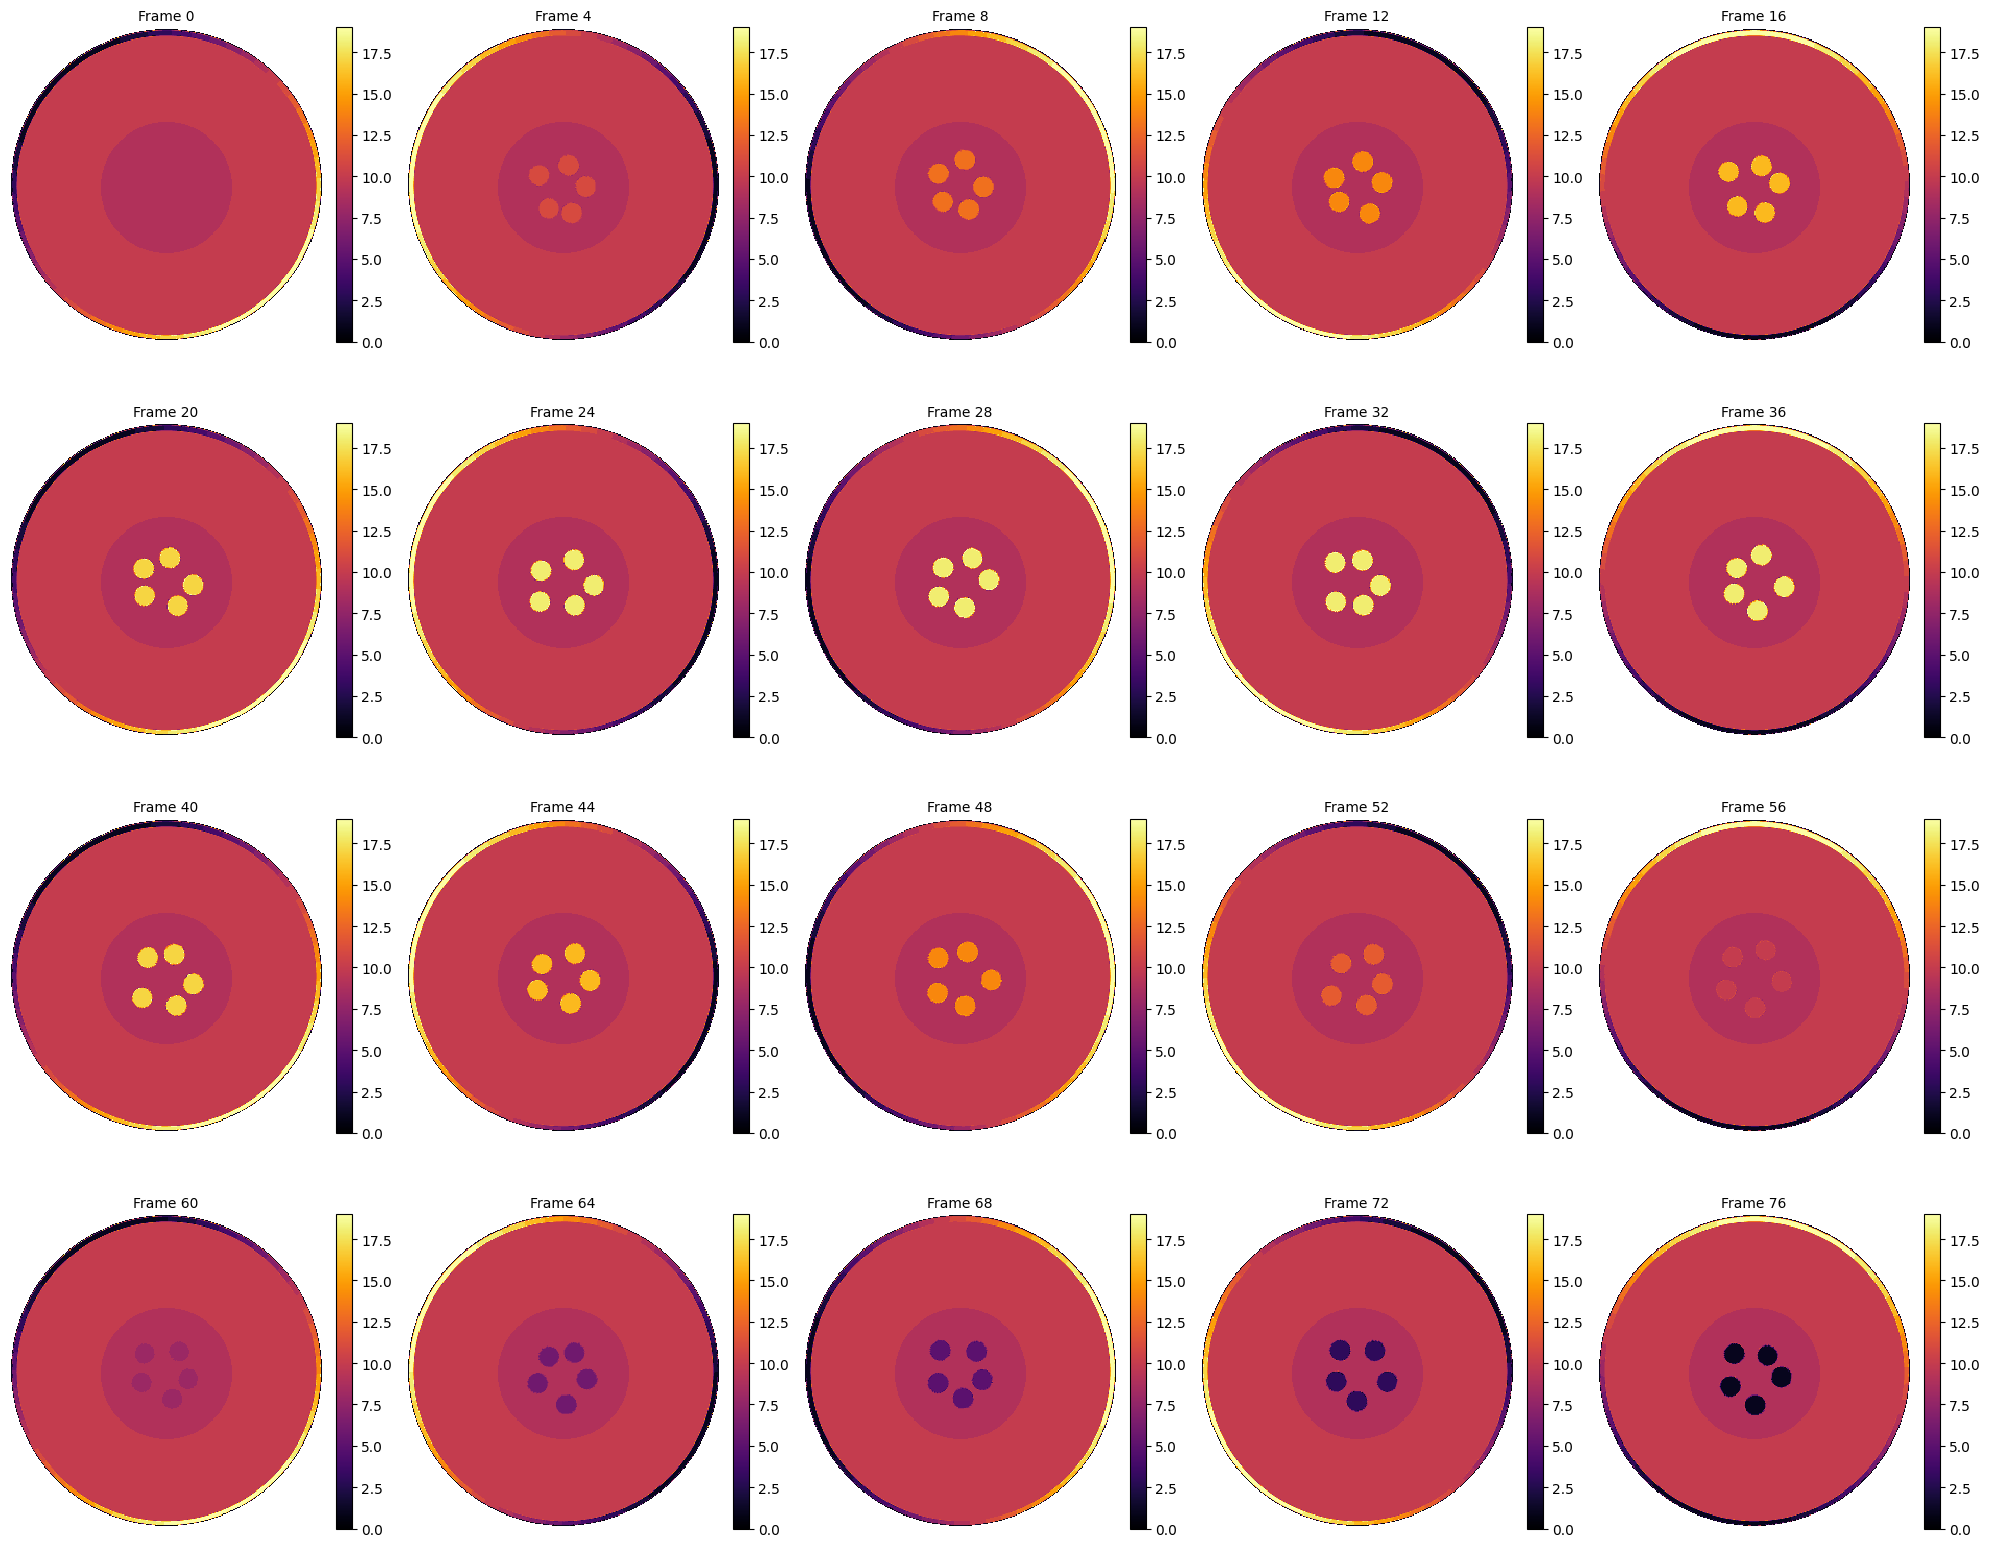

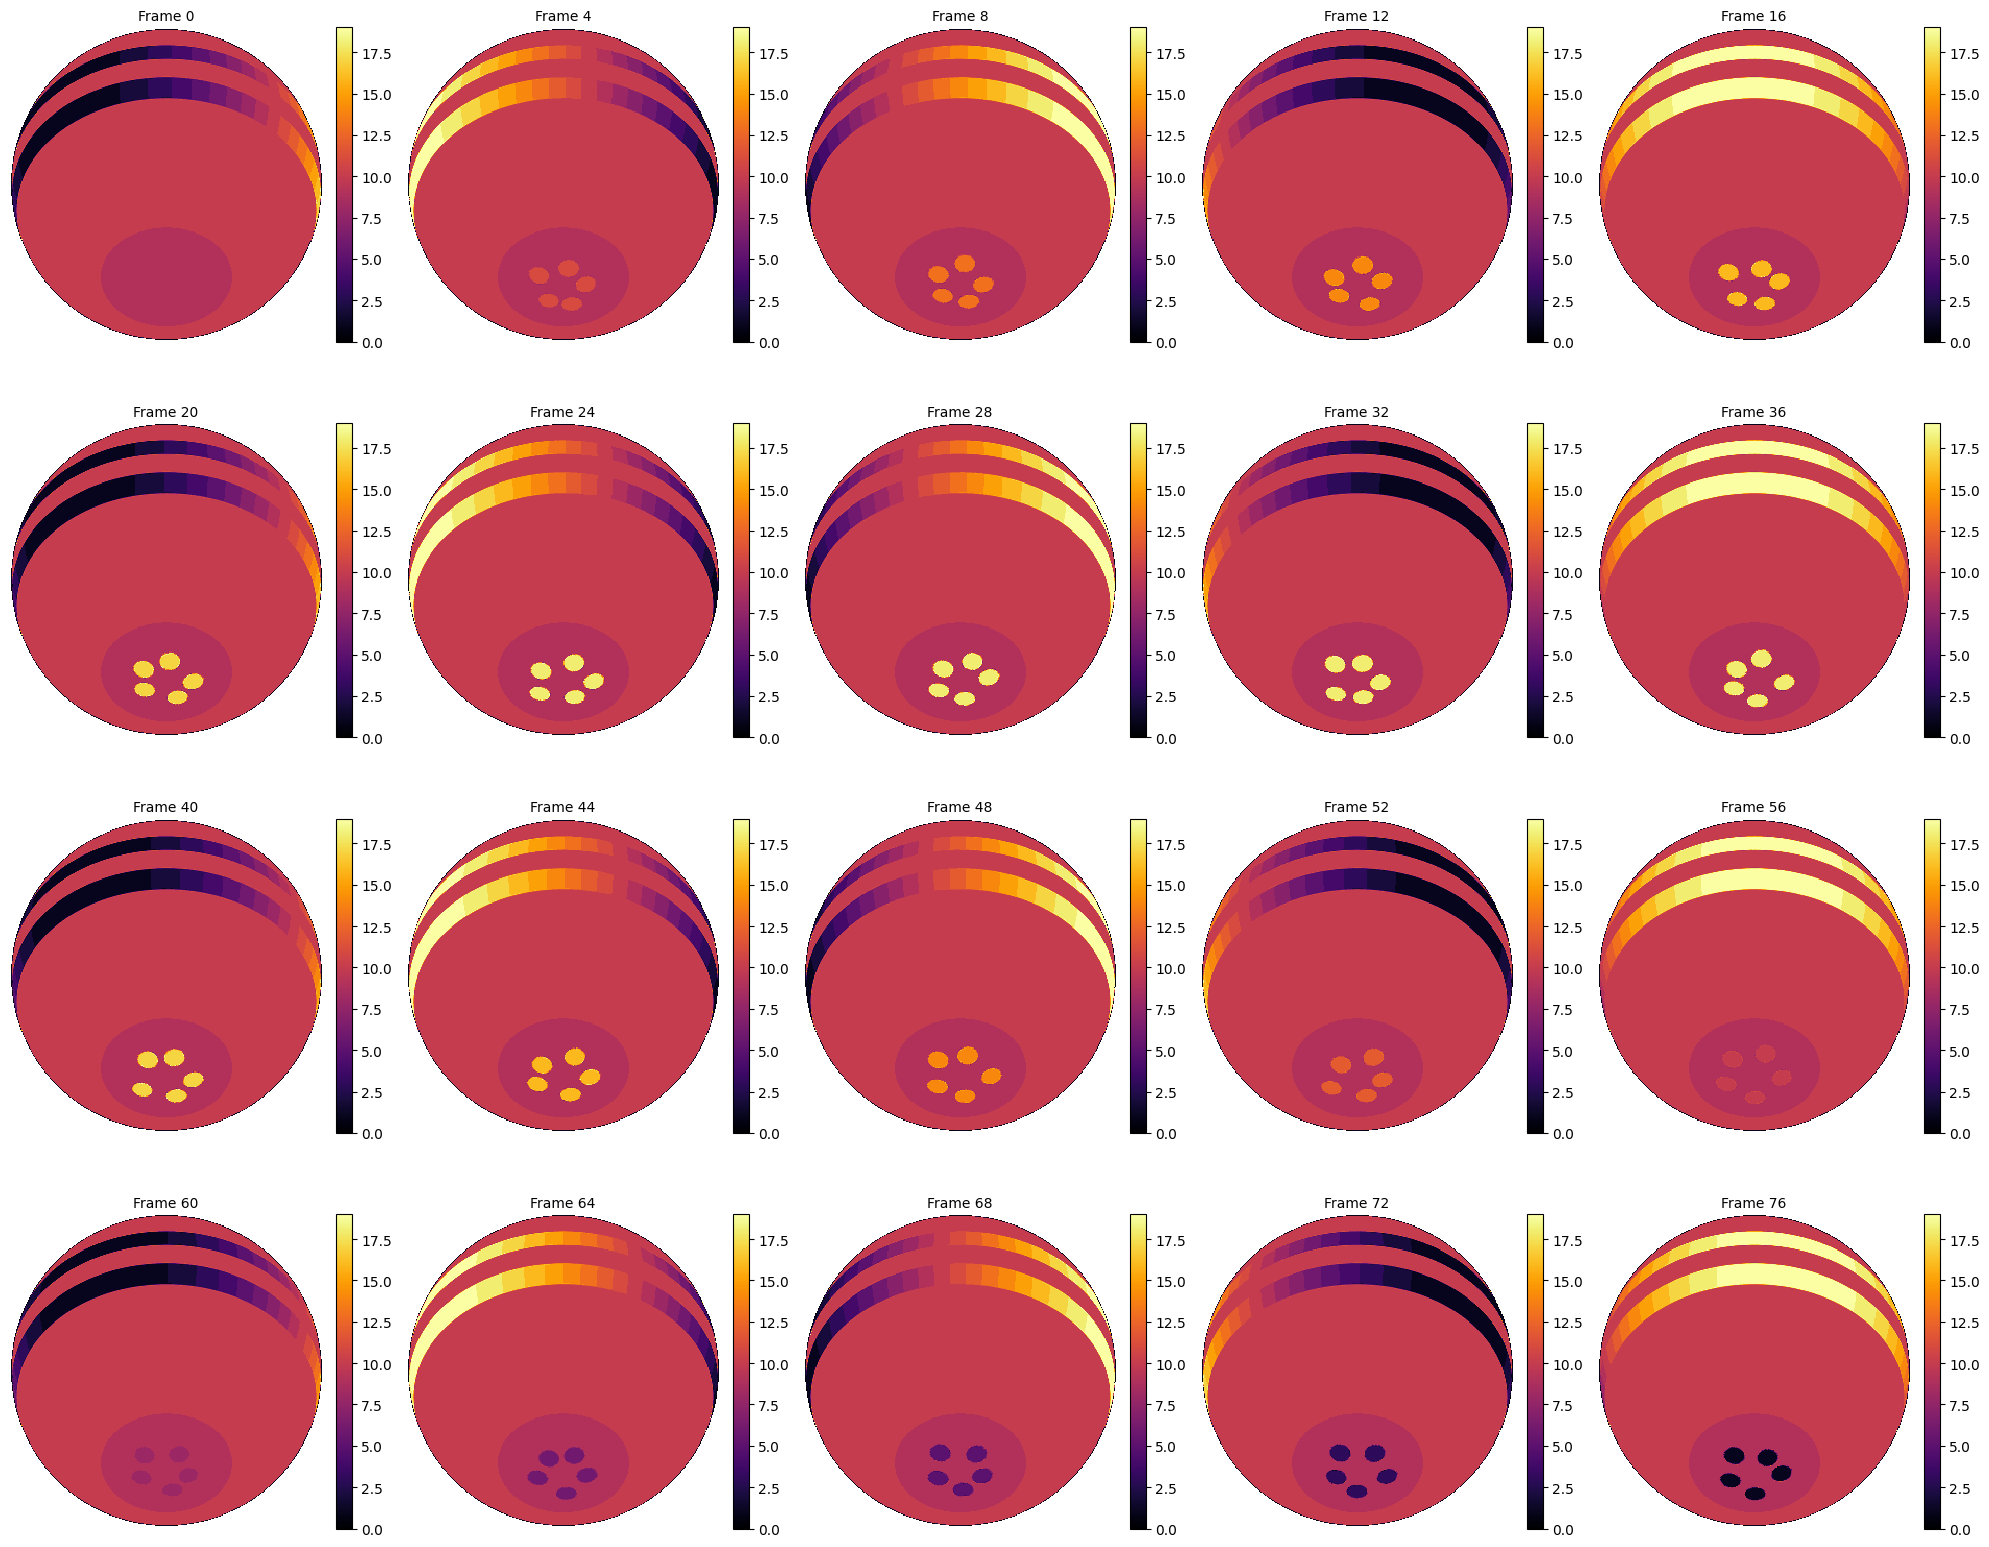

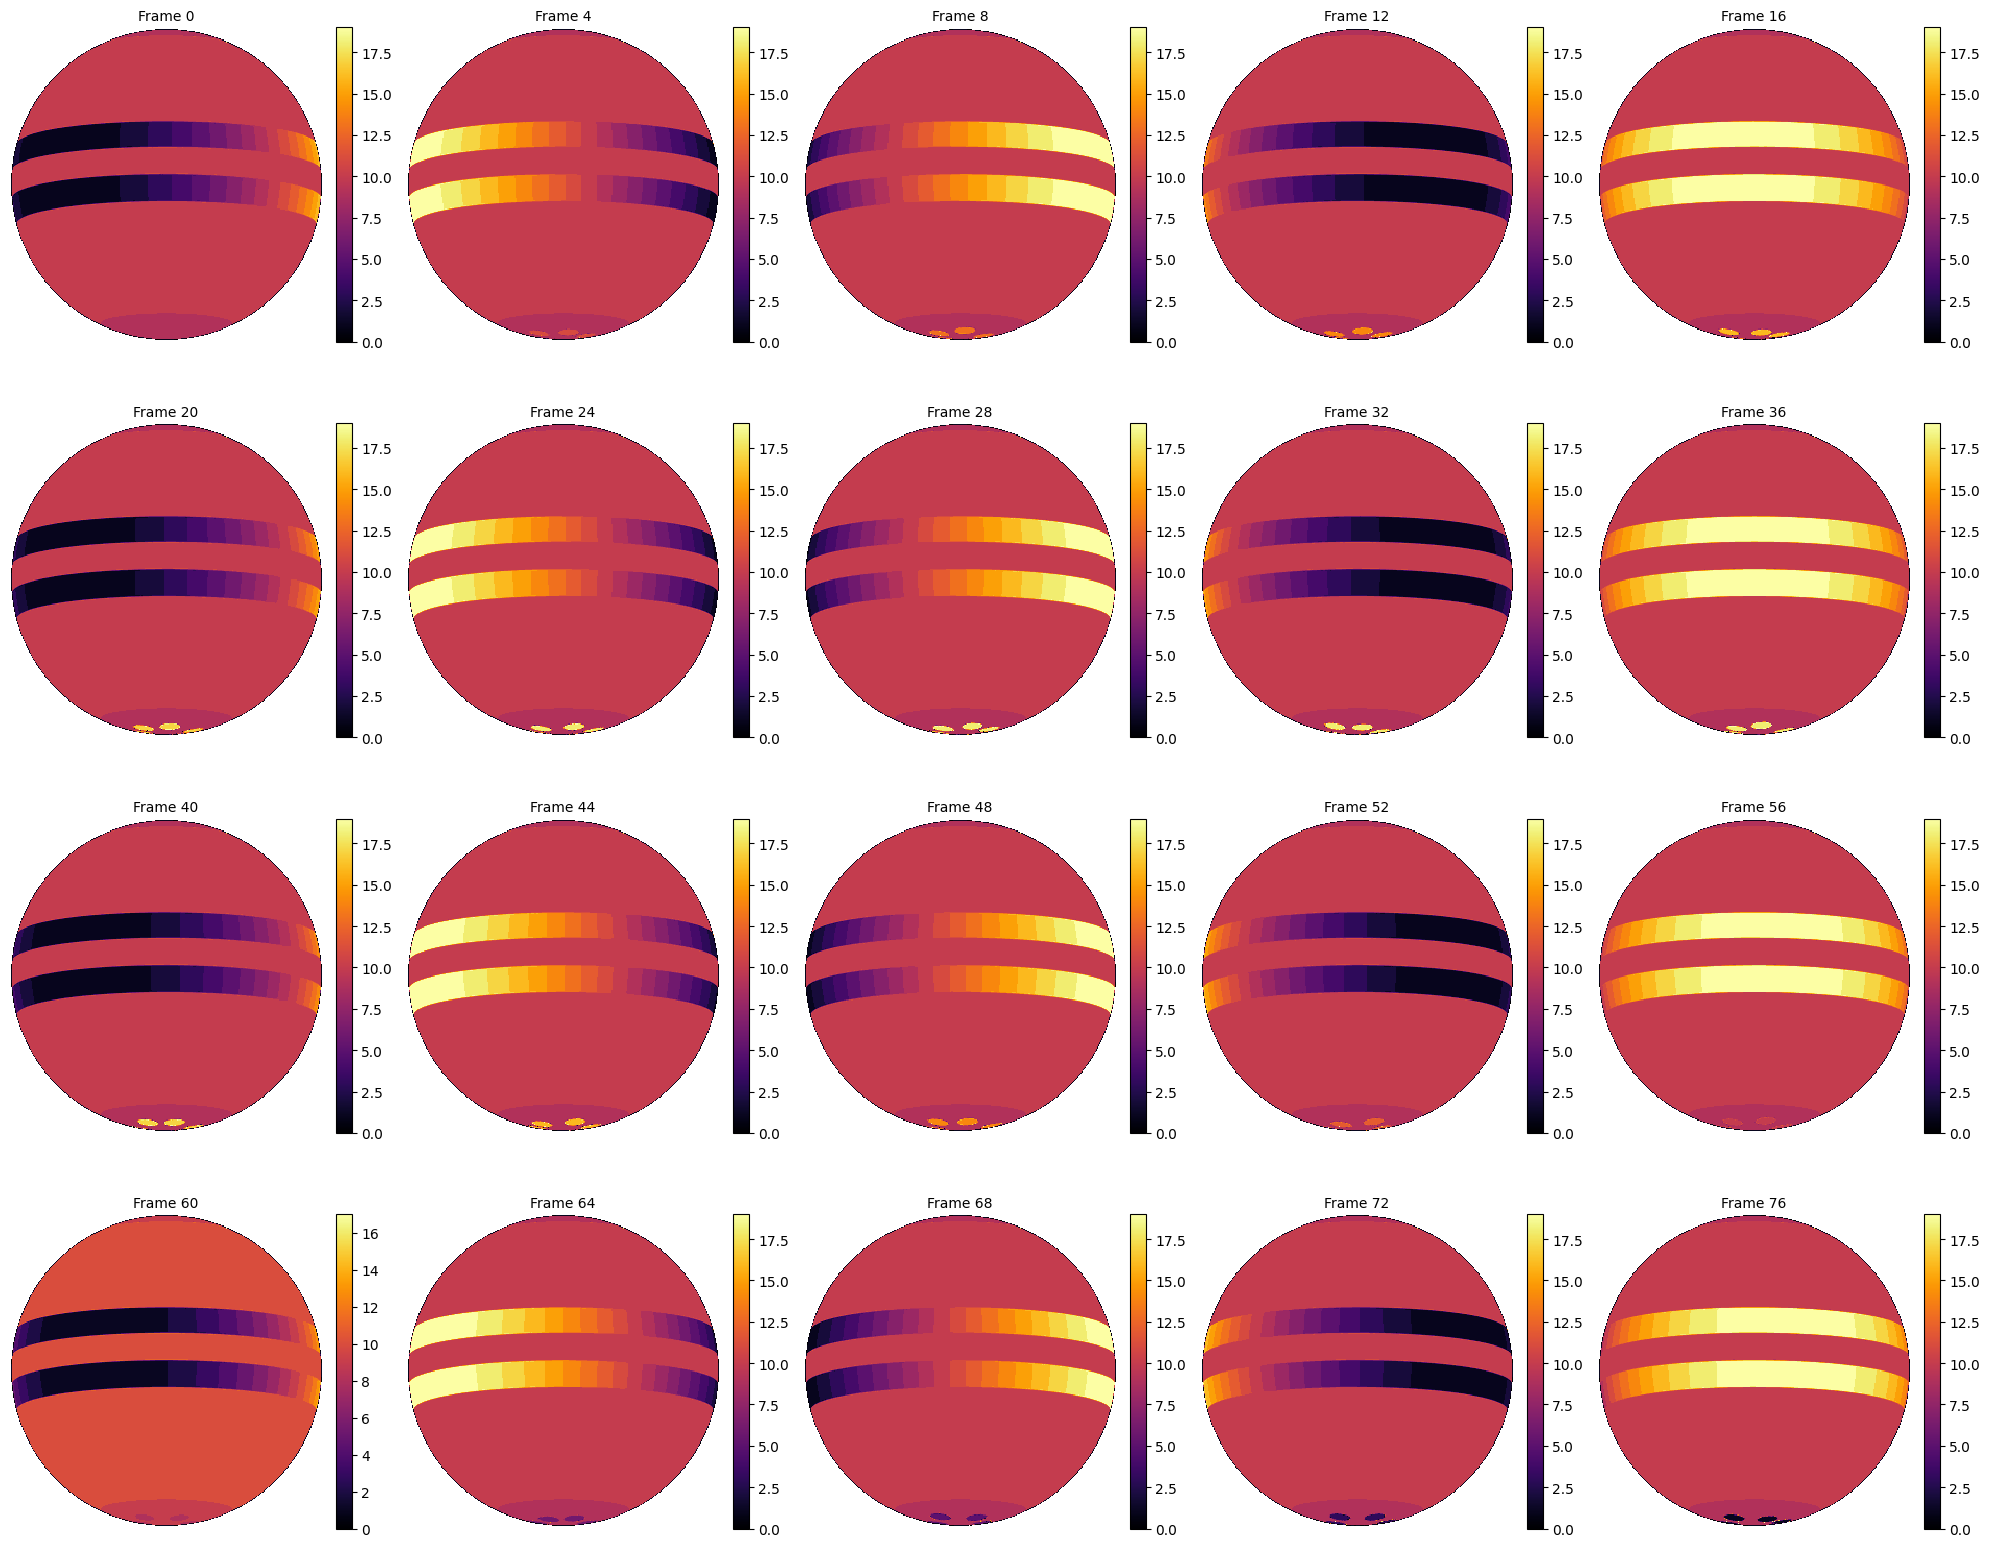

In [ ]:

save = False
######## Plot all composite images in a grid (5 columns)

# for inc in codecs.keys():
for inc in ['0', '40', '80']:    
    codecs_ts = codecs[inc]
    
    n_frames = 20
    n_cols = 5
    n_rows = int(np.ceil(n_frames / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

    # Flatten axes for easier indexing
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    # Plot each frame
    for j in range(n_frames):
        i = 4*j  # Select every 3rd frame for visibility
        ax = axes_flat[j]
        composite = codecs_ts[i]['composite']
        frame_idx = codecs_ts[i]['frame']
        
        im = ax.imshow(composite, cmap='inferno', interpolation='nearest')
        ax.set_title(f'Frame {frame_idx}', fontsize=10)
        ax.axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused subplots
    for i in range(n_frames, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    if save:
        outpath = os.path.join(dirPath, f'all_frames_i={inclin}.pdf')
        plt.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"Saved {n_frames}-panel image for i={inclin}")
    plt.show()
    plt.close()

### 2 - 2x3 Plot the summary panel: Spectra, Lightcurve, Periodogram, Images


### Visualizing Spectra ###
Saved summary panel for i=0 to spectra_analysis_i=0.pdf


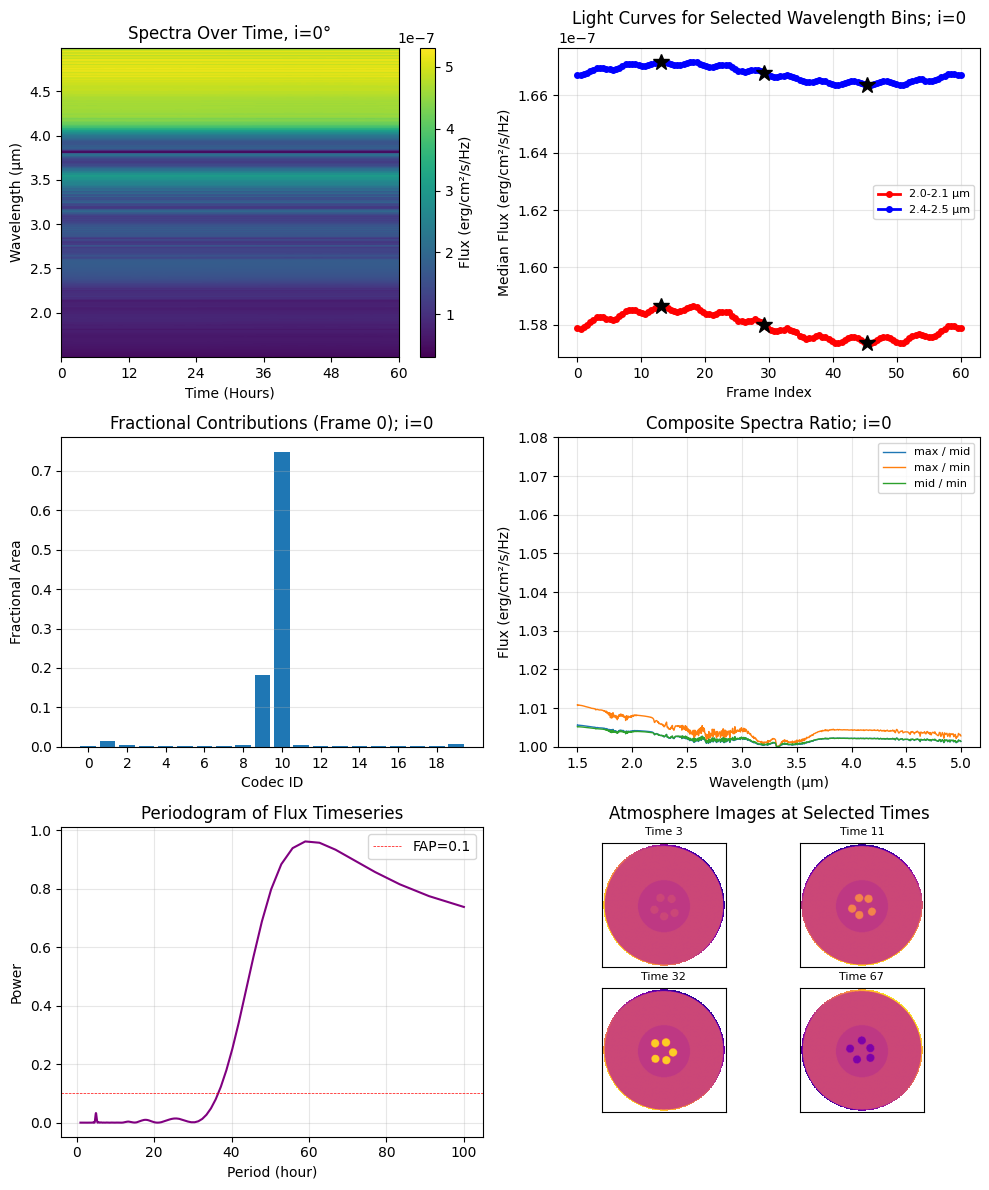


### Visualizing Spectra ###
Saved summary panel for i=10 to spectra_analysis_i=10.pdf


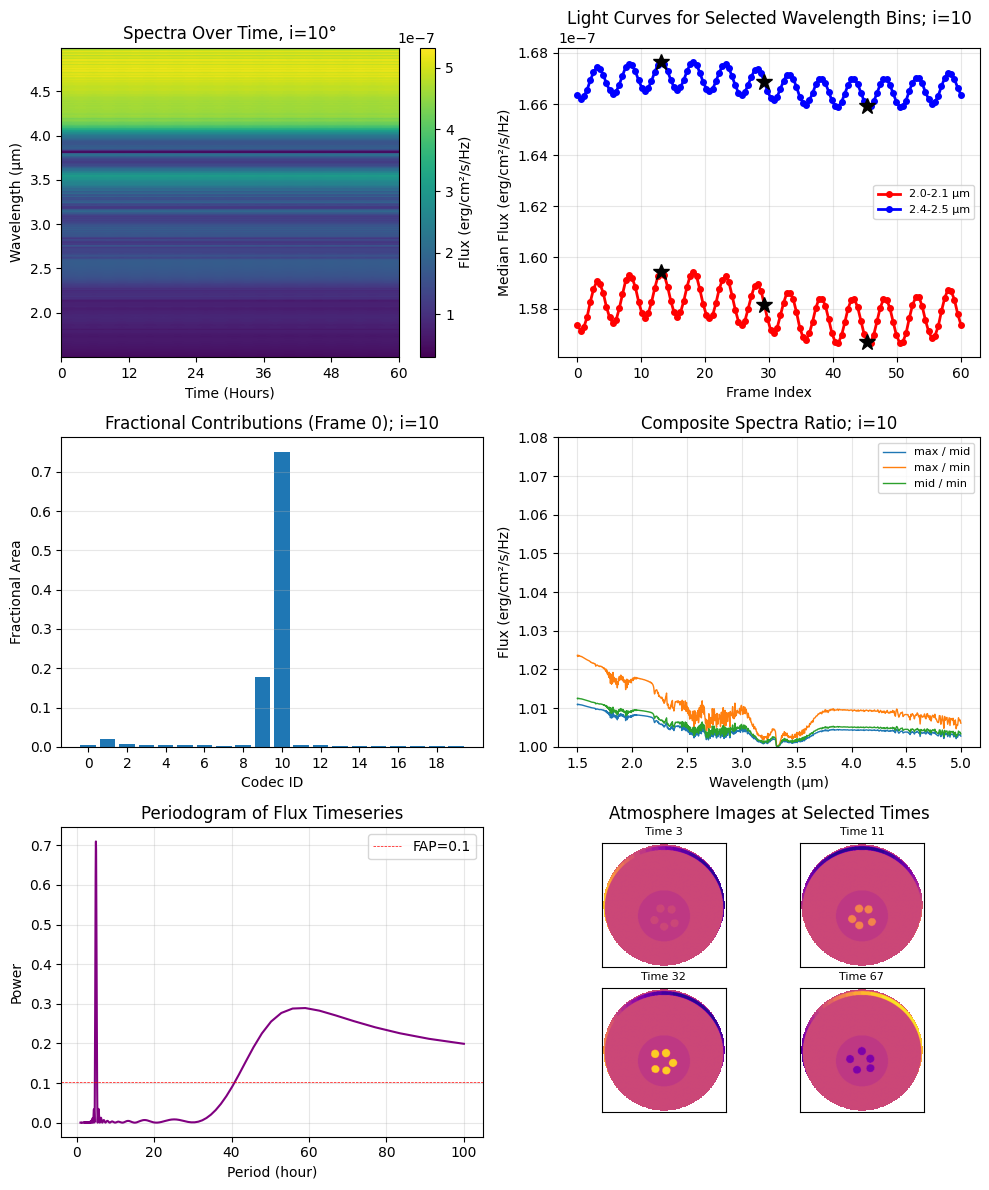


### Visualizing Spectra ###
Saved summary panel for i=20 to spectra_analysis_i=20.pdf


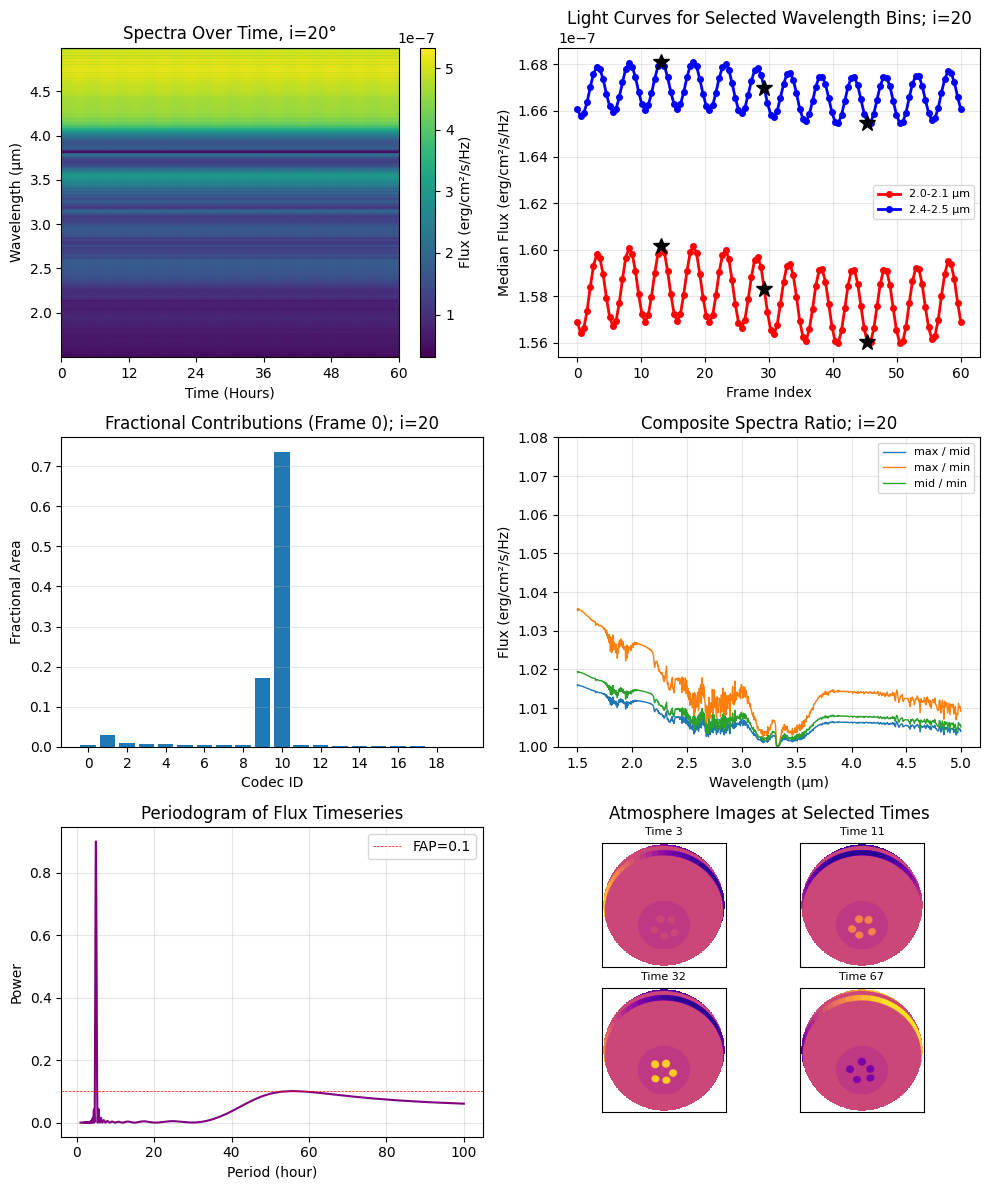


### Visualizing Spectra ###
Saved summary panel for i=30 to spectra_analysis_i=30.pdf


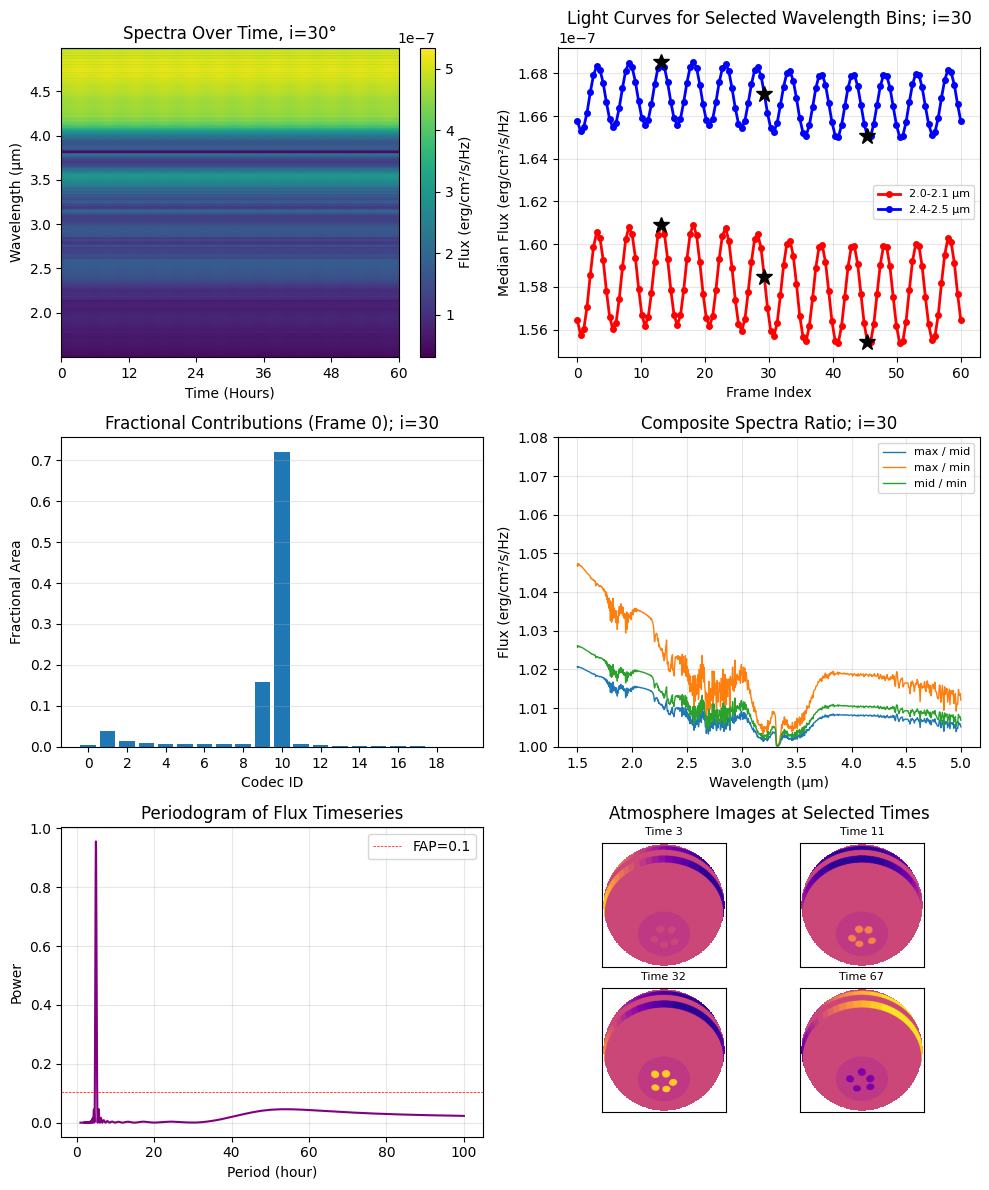


### Visualizing Spectra ###
Saved summary panel for i=40 to spectra_analysis_i=40.pdf


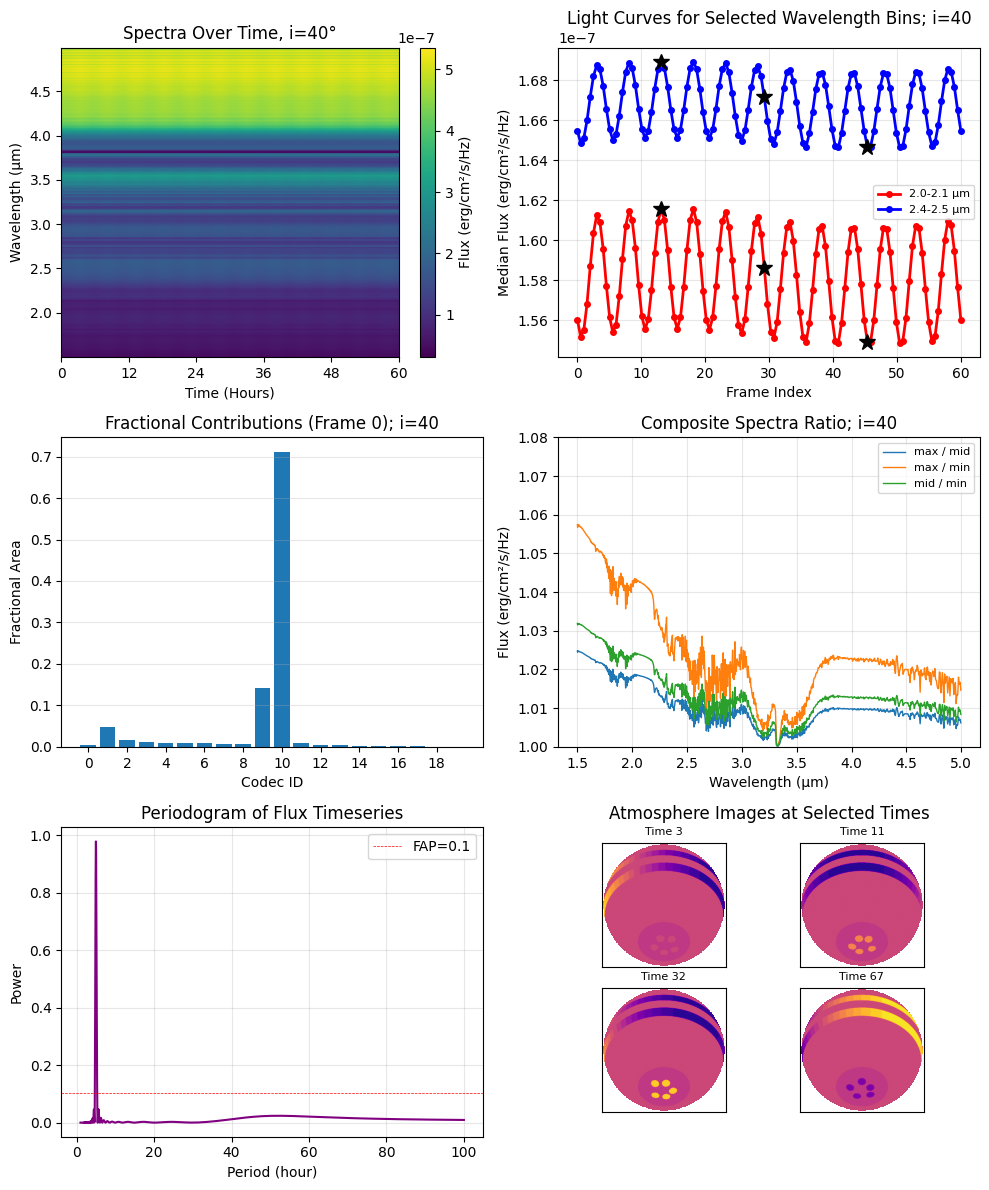


### Visualizing Spectra ###
Saved summary panel for i=50 to spectra_analysis_i=50.pdf


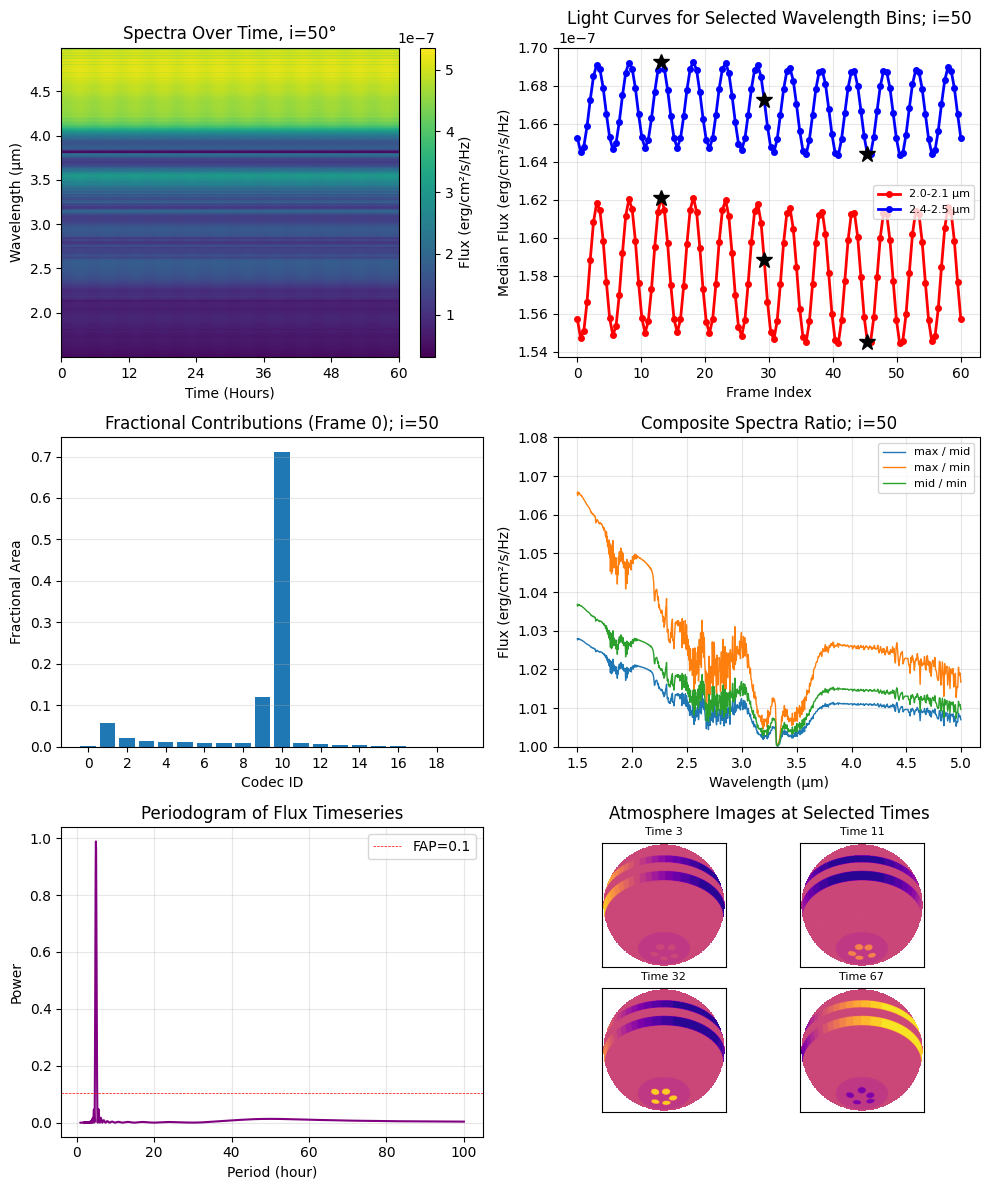


### Visualizing Spectra ###
Saved summary panel for i=60 to spectra_analysis_i=60.pdf


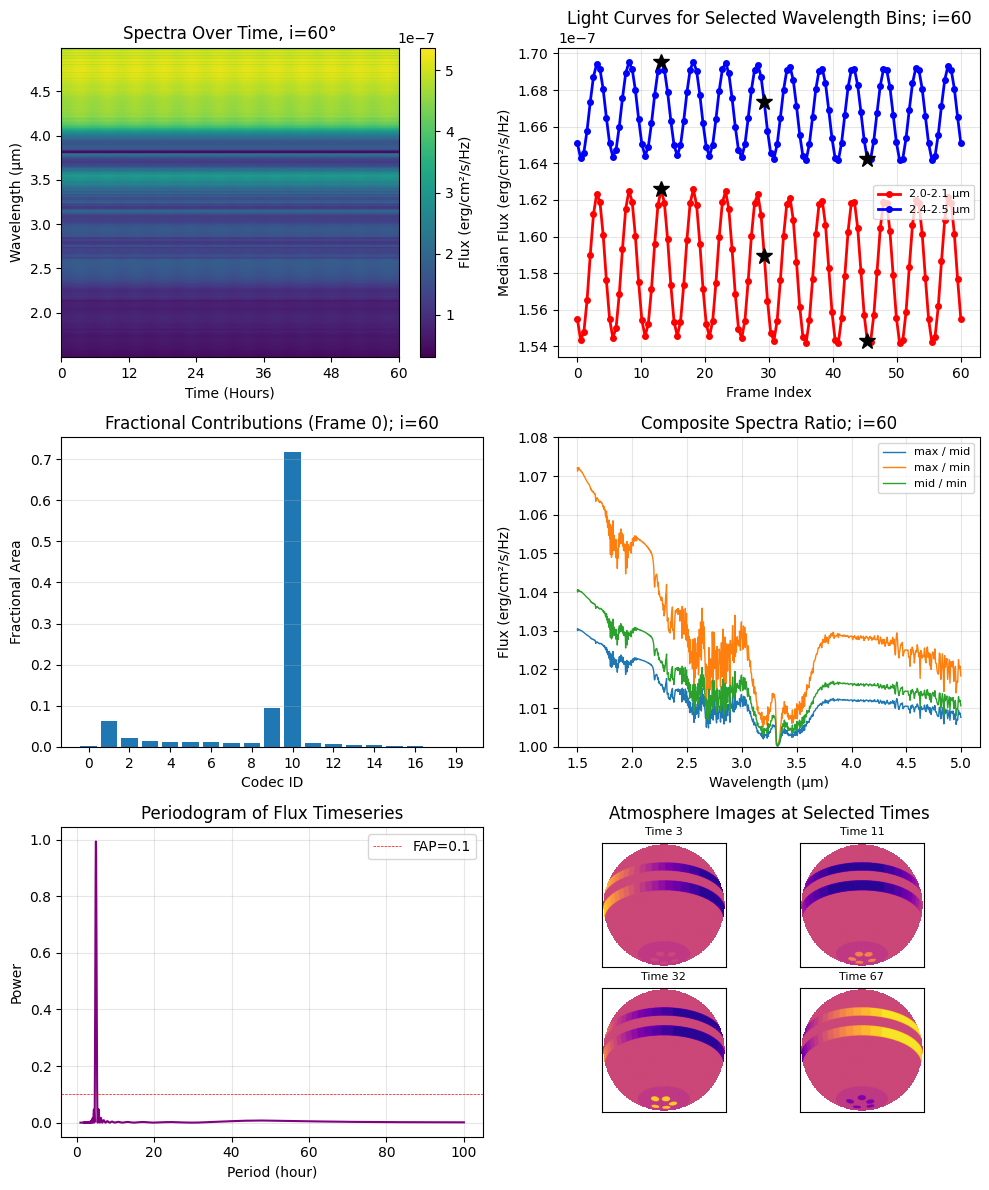


### Visualizing Spectra ###
Saved summary panel for i=70 to spectra_analysis_i=70.pdf


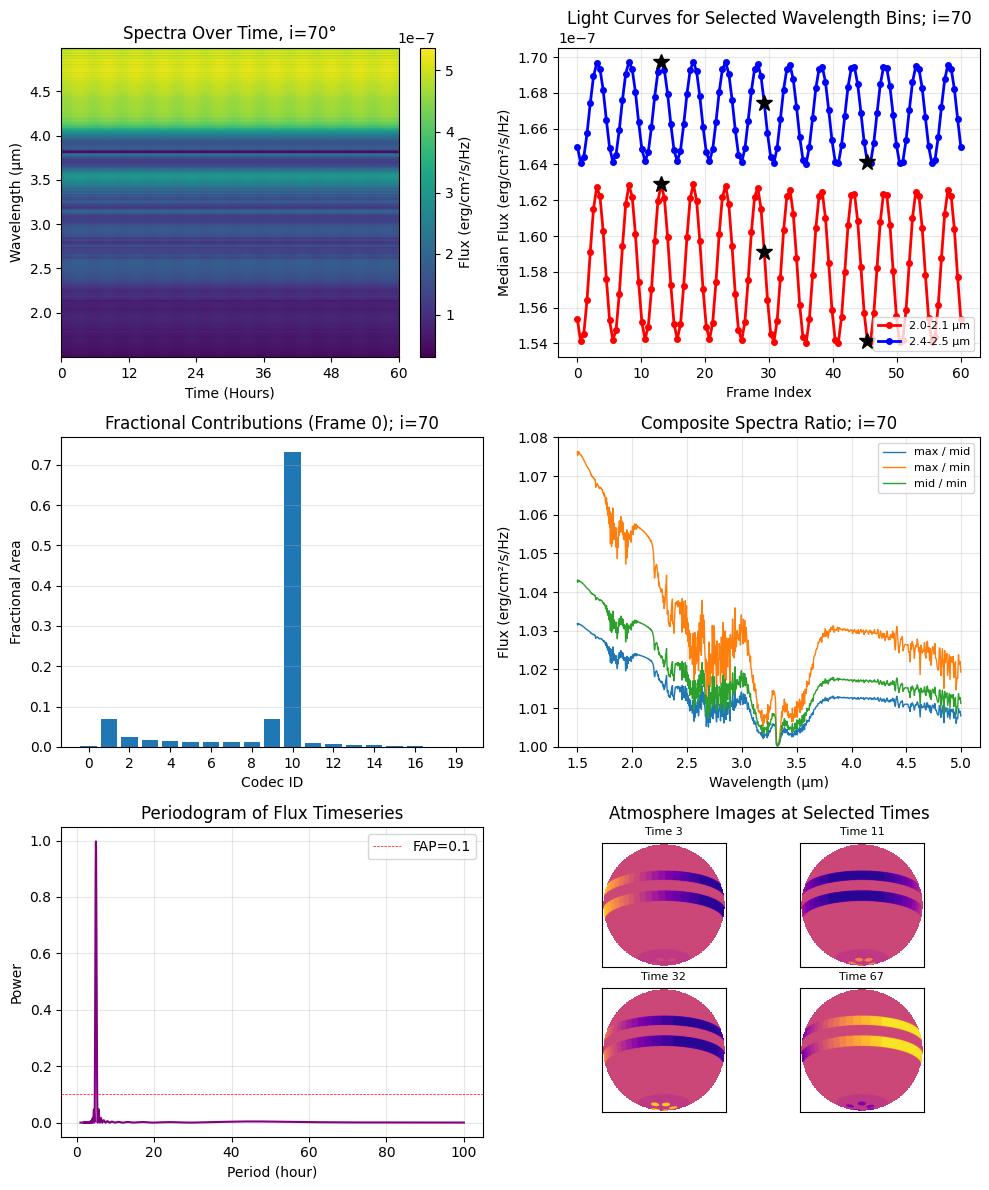


### Visualizing Spectra ###
Saved summary panel for i=80 to spectra_analysis_i=80.pdf


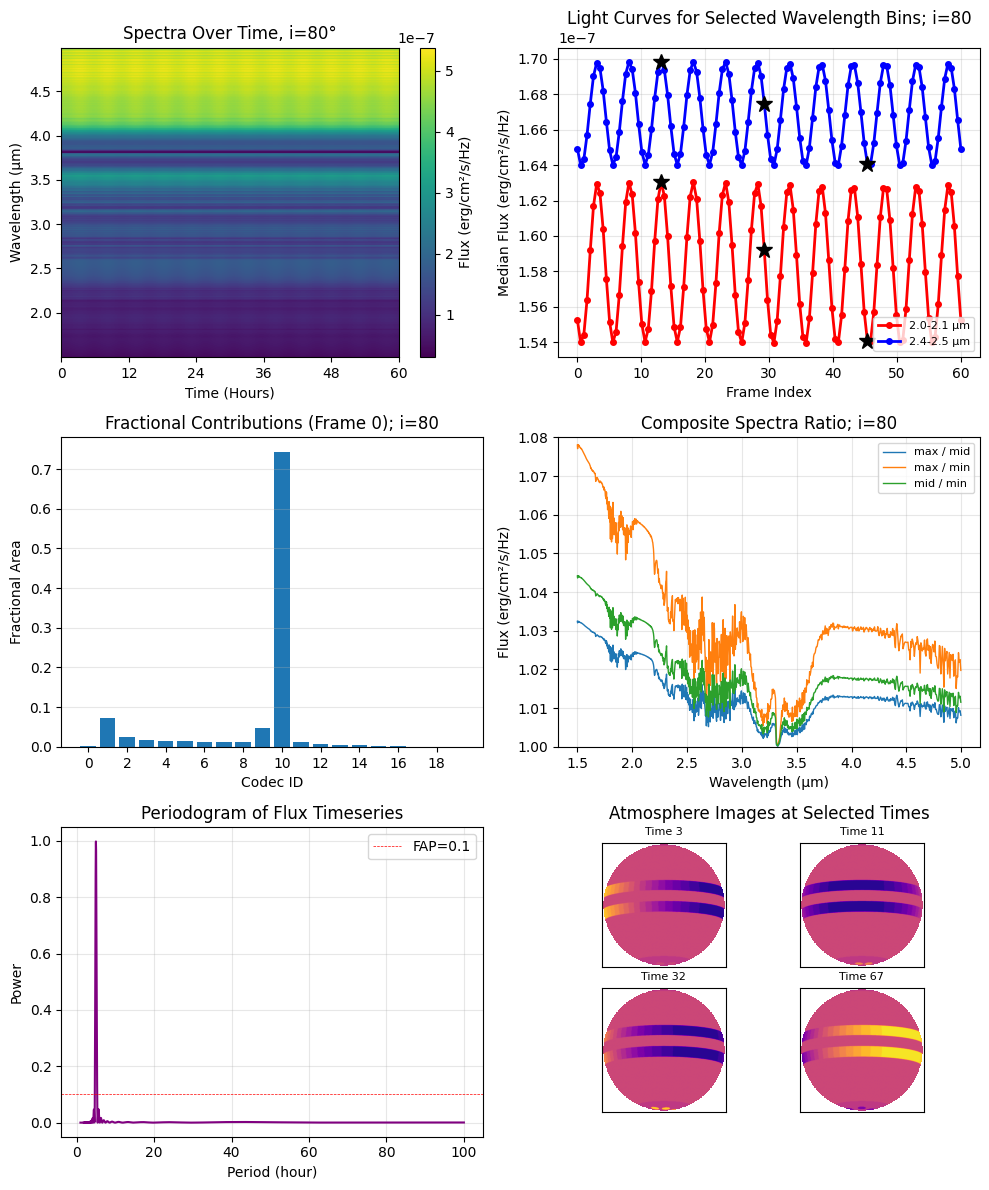


### Visualizing Spectra ###
Saved summary panel for i=90 to spectra_analysis_i=90.pdf


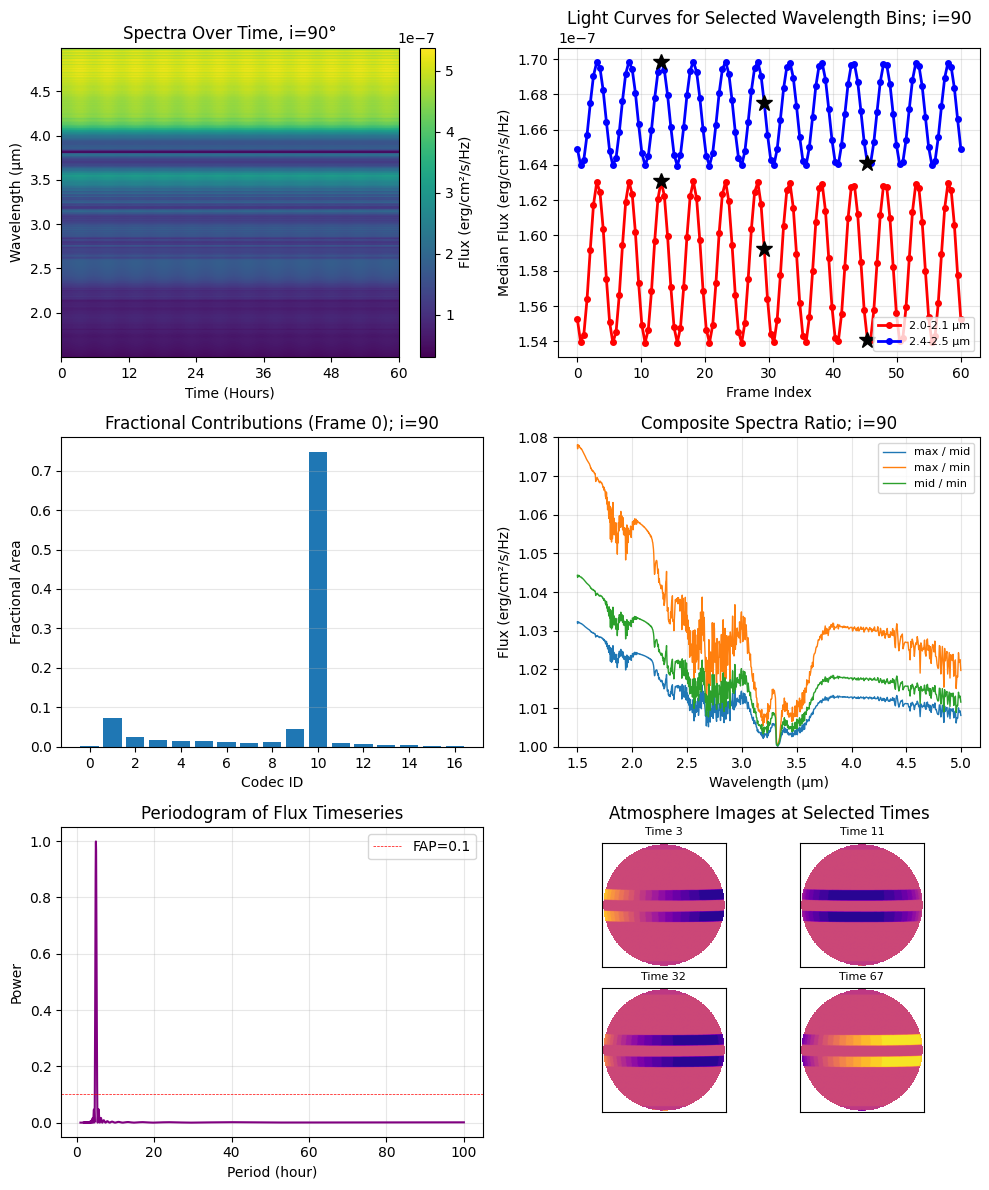

In [135]:
save = True
# save = False

######## Summary plot: Spectra, Lightcurves, Periodogram, Image ########
for inclin in specs.keys():
# for inclin in ['40']:
    composite_spectra_ts = specs[inclin]
    # ===== Visualization: Compare Individual vs Composite =====
    print("\n### Visualizing Spectra ###")

    fig, axes = plt.subplots(3, 2, figsize=(10, 12))

    # ===== Plot 1: The image of time-series spectrum =====
    ax = axes[0, 0]
    time_indices = results[inclin]['time_array']
    time_indices.sort()
    flux_matrix = []
    for keys in specs[inclin].keys():
        _, wave_i, flux_i = specs[inclin][keys].values()
        flux_matrix.append(flux_i)

    flux_matrix = np.array(flux_matrix)

    # Plot the 2D image
    im = ax.imshow(flux_matrix.T, aspect='auto', origin='lower', 
                    extent=[time_indices[0], time_indices[-1], wave_i[0], wave_i[-1]],
                    cmap='viridis')

    ax.set_xlabel('Time (Hours)')
    ax.set_xticks(np.linspace(time_indices[0], time_indices[-1], num=6, dtype=int))
    ax.set_ylabel('Wavelength (μm)')
    ax.set_title(f'Spectra Over Time, i={inclin}°')
    plt.colorbar(im, ax=ax, label='Flux (erg/cm²/s/Hz)')

    # ===== Plot 2: Light curves for specific wavelength bin =====
    ax = axes[0,1]

    # Define wavelength bins
    wavebin = [(2.0, 2.1, 'red'),
            (2.4, 2.5, 'blue'),]

    # Extract light curves for each bin
    for wmin, wmax, color in wavebin:
        flux_timeseries = []
        
        for keys in specs[inclin]:
            frame_i, wave_i, flux_i = composite_spectra_ts[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_timeseries.append(median_flux)
        
        # Plot light curve
        ax.plot(time_indices, flux_timeseries, 
                marker='o', linestyle='-', color=color, 
                linewidth=2, markersize=4,
                label=f'{wmin}-{wmax} μm')

        # Highlight specific timepoint
        for i,xid in enumerate([26, 58, 90]):
            color_list = ['orange', 'green', 'purple']
            ax.plot(time_indices[xid], flux_timeseries[xid], ls='', 
                    marker='*', markersize=12, color='k')

    ax.set_xlabel('Frame Index')
    ax.set_ylabel('Median Flux (erg/cm²/s/Hz)')

    ax.set_title(f'Light Curves for Selected Wavelength Bins; i={inclin}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('linear')

    # ===== Plot 3: Fractional contributions =====

    # Process a Single Frame for Reference
    frame_idx = 0
    fractions = codecs[inclin][frame_idx]['fractions']

    ax = axes[1, 0]
    codec_ids = list(fractions['fractions'].keys())
    frac_values = list(fractions['fractions'].values())
    ax.bar(codec_ids, frac_values)
    ax.set_xlabel('Codec ID')
    ax.set_xticks(codec_ids[::2])  # Show every other tick
    ax.set_ylabel('Fractional Area')
    ax.set_title(f'Fractional Contributions (Frame {frame_idx}); i={inclin}')
    ax.grid(True, alpha=0.3, axis='y')

    # ### ===== Add inset atm images to axes[1, 1] ======
    # inset_ax = ax.inset_axes([0.05, 0.3, 0.17*1.95, 0.25*2])  # [x, y, width, height]
    # inset_ax.imshow(specs_ts[15]['composite'], cmap='plasma', aspect='auto')
    # inset_ax.set_xticks([])
    # inset_ax.set_yticks([])
    # inset_ax.set_title('Clouds-codec', fontsize=8)

    # ===== Plot 4: Composite spectra evolution over time =====
    ax = axes[1, 1]
    # for i in range(0, len(composite_spectra_ts), 10):  # Every 10th frame
    #     frame_i, wave_i, flux_i = composite_spectra_ts[i]
    #     ax.plot(wave_i, flux_i, alpha=1.0, lw=0.5, label=f'Frame {frame_i}')
    
    frameA, waveA, fluxA = composite_spectra_ts[26].values()
    frameB, waveB, fluxB = composite_spectra_ts[58].values()
    frameC, waveC, fluxC = composite_spectra_ts[90].values()

    ax.plot(waveA, fluxA/fluxB, lw=1, label=f'max / mid')
    ax.plot(waveA, fluxA/fluxC, lw=1, label=f'max / min')
    ax.plot(waveA, fluxB/fluxC, lw=1, label=f'mid / min')

    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Flux (erg/cm²/s/Hz)')
    ax.set_title(f'Composite Spectra Ratio; i={inclin}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1.0, 1.08)

    # ===== Plot 5: Periodogram of second lightcurve in hours x-axis =====
    ax = axes[2, 0]

    from PyAstronomy.pyTiming import pyPeriod
    freqs = np.linspace(0.01, 1, 1000) 
    flux_timeseries = np.array(flux_timeseries)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_indices, flux_timeseries, 0.001*flux_timeseries), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='purple')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={fap}')
    ax.set_xlabel('Period (hour)')
    ax.set_ylabel('Power')
    ax.set_title('Periodogram of Flux Timeseries')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ===== Plot 6: 2x2 images at t=0, 10, 20, 30
    ax = axes[2, 1]
    timepoints = [3, 11, 32, 67]
    n_tp = len(timepoints)
    for i, tp in enumerate(timepoints):
        img = codecs[inclin][tp]['composite']
        sub_ax = ax.inset_axes([
        0.05 + (i % 2) * 0.47, 
        0.55 - (i // 2) * 0.47, 
        0.4, 0.4
        ])
        im = sub_ax.imshow(img, cmap='plasma', vmin=0, vmax=n,
                                aspect='equal')  # Set aspect to 'equal'
        sub_ax.set_xticks([])
        sub_ax.set_yticks([])
        sub_ax.set_title(f'Time {tp}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Atmosphere Images at Selected Times')
    # set all spine frames to be invisible
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ==============================
    plt.tight_layout()
    handle = f'spectra_analysis_i={inclin}.pdf'
    save_path = os.path.join(dirPath, handle)
    if save:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved summary panel for i={inclin} to {handle}")
    plt.show()
    plt.close()

Text(0, 0.5, 'J-K Color (mag, relative)')

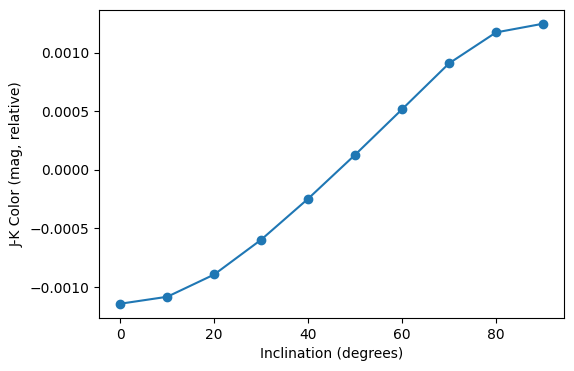

In [106]:
colors = []
for inclin in specs.keys():
    composite_spectra_ts = specs[inclin]
    mean_flux = np.zeros_like(wave_i)
    for keys in specs[inclin]:
        _, wave_i, flux_i = composite_spectra_ts[keys].values()
        mean_flux += flux_i
    mean_flux /= len(specs[inclin].keys())
    
    color_J_mask = (wave_i >= 1.5) & (wave_i <= 1.6)
    color_K_mask = (wave_i >= 2.2) & (wave_i <= 2.4)

    color_J_flux = np.mean(mean_flux[color_J_mask])
    color_K_flux = np.mean(mean_flux[color_K_mask])
    colorJK = 2.5 * np.log10(color_J_flux / color_K_flux)

    colors.append((float(inclin), colorJK))

# Plot color vs inclination
fig, ax = plt.subplots(figsize=(6,4))
inclinations, colorJKs = zip(*colors)
color_mean = np.mean(colorJKs)
ax.plot(inclinations, colorJKs - color_mean, marker='o', linestyle='-')
ax.set_xlabel('Inclination (degrees)')
ax.set_ylabel('J-K Color (mag, relative)')